In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from evaluation.portfolio import portfolio_roi, portfolio_kelly, portfolio_breakdown

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')
ts = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season.parquet')
final = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season_final.parquet')
thr = json.load(open('C:/Users/twluc/frame/01_data/02_features/thresholds.json'))

In [4]:
# some combinations give low p-value - worth exploring further.

In [5]:
final = (
    final
    .sort_values(['league', 'season', 'season_points_avg', 'season_goals_diff_avg'],
                 ascending=[True, True, False, False])
    .assign(standing=lambda df: df.groupby(['league', 'season']).cumcount() + 1)
)

In [6]:
def plot_foragst_scatter(df, group):
    groups = df[group].unique()
    colors = dict(zip(groups, plt.cm.tab20.colors))

    fig, ax = plt.subplots(figsize=(9, 7))
    for grp_val, grp in df.groupby(group):
        ax.scatter(grp['season_goals_for_avg'], grp['season_goals_agst_avg'], label=grp_val, alpha=0.6, s=20)

    for v in [thr['goals_foragst_p33'], thr['goals_foragst_p67']]:
        ax.axvline(v, color='gray', linewidth=0.6, linestyle='--')
        ax.axhline(v, color='gray', linewidth=0.6, linestyle='--')

    ax.set_xlabel('goals scored avg'); ax.set_ylabel('goals conceded avg')

    ax.set_xlim(0, 3) 
    ax.set_ylim(0, 3)
    
    ax.legend(markerscale=2, fontsize=8)
    
    plt.tight_layout()
    plt.show()

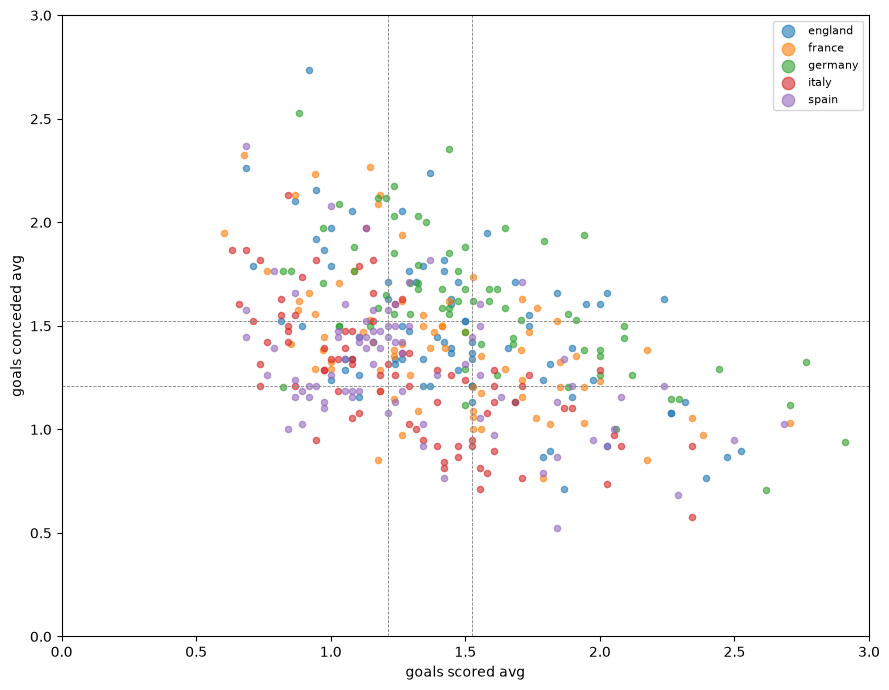

In [7]:
plot_foragst_scatter(final,'league')

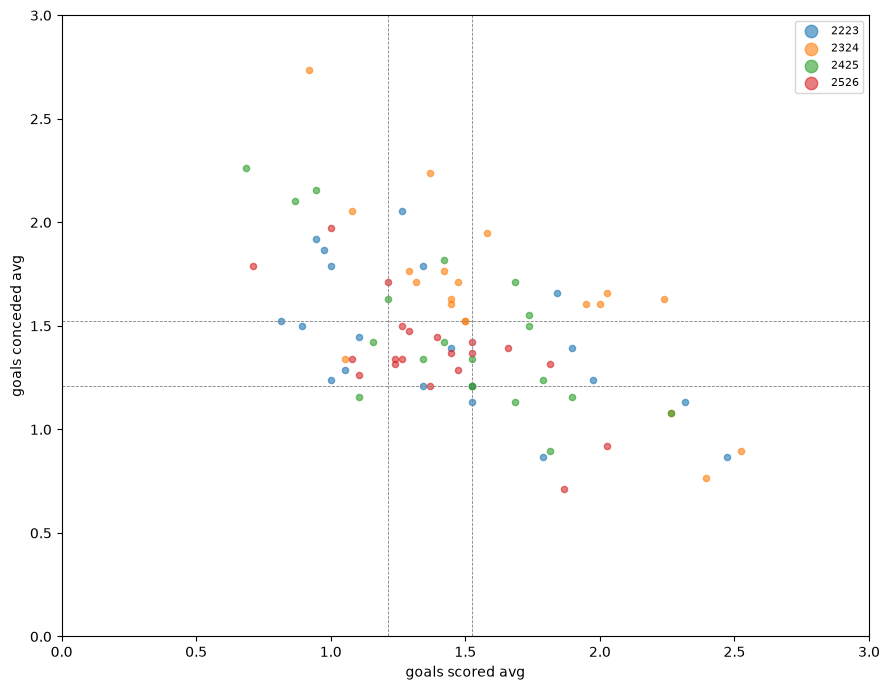

In [8]:
england = final[final['league']=='england']
plot_foragst_scatter(england,'season')

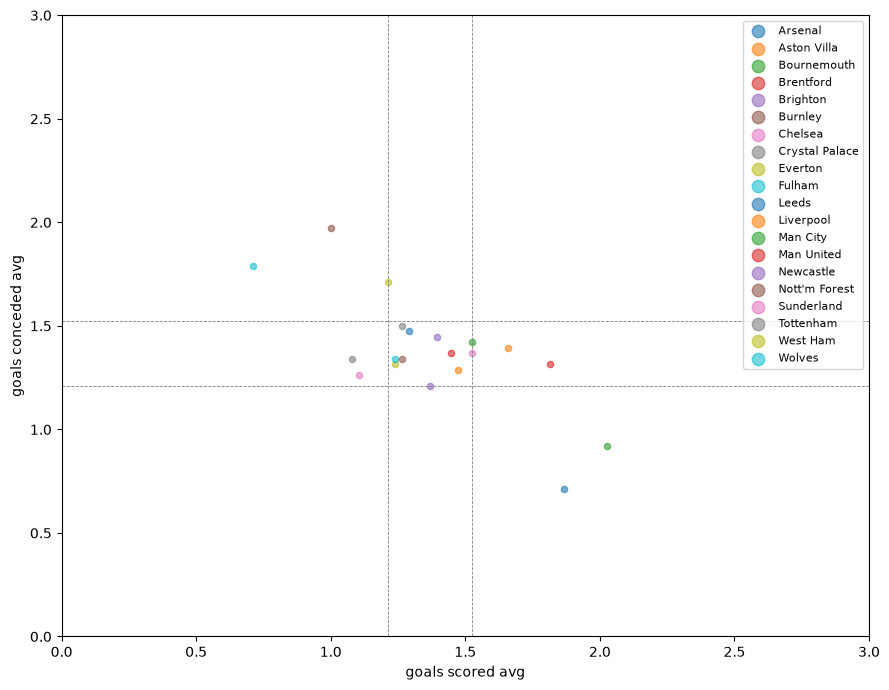

In [9]:
england2526 = final.query("league == 'england' and season == '2526'")
plot_foragst_scatter(england2526,'team')

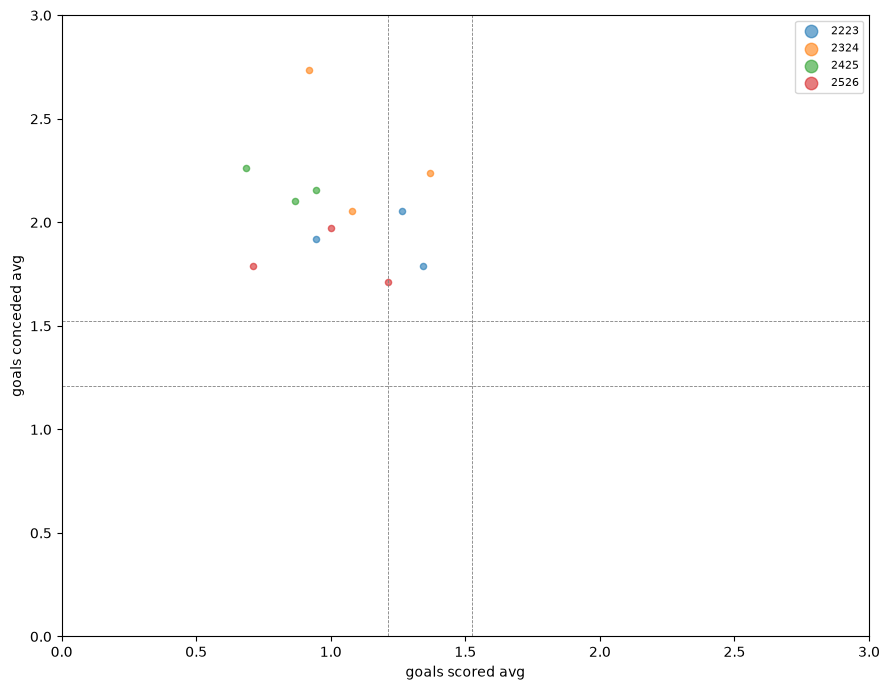

In [10]:
query = "league == 'england' and standing >= 18"
plot_foragst_scatter(final.query(query),'season')

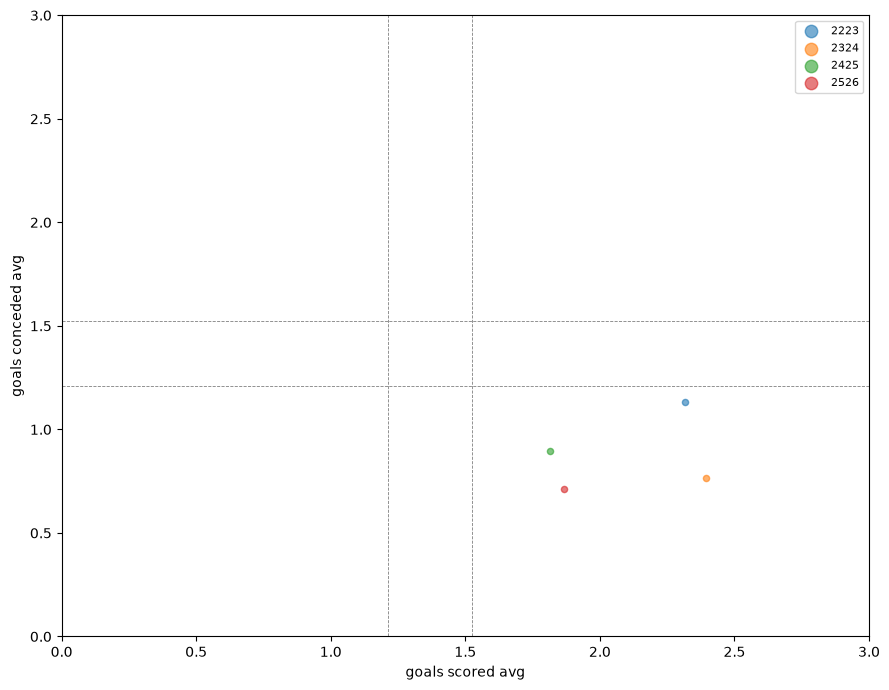

In [11]:
query = "team == 'Arsenal'"
plot_foragst_scatter(final.query(query),'season')

In [12]:
final.groupby(['league', 'season_goals_for_cat3q']).size().unstack()[['high','medium','low']]

season_goals_for_cat3q,high,medium,low
league,,,
england,33,25,22
france,30,18,26
germany,32,24,16
italy,22,18,40
spain,22,15,43


In [13]:
final.groupby(['league', 'season_goals_agst_cat3q']).size().unstack()[['high','medium','low']]

season_goals_agst_cat3q,high,medium,low
league,,,
england,33,28,19
france,23,29,22
germany,44,18,10
italy,18,26,36
spain,15,30,35


In [14]:
sub = abt[abt['hmt_game_number'] > 8]
cols = ['hmt_season_goals_for_cat2m', 'hmt_season_goals_agst_cat2m',
        'awt_season_goals_for_cat2m', 'awt_season_goals_agst_cat2m']

groups = {k: g for k, g in sub.groupby(cols)}
results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")


('high', 'high', 'low', 'high') roi=0.325  n=246  p=0.005
('low', 'high', 'high', 'high') roi=0.150  n=269  p=0.150
('high', 'low', 'low', 'high') roi=0.077  n=558  p=0.364
('low', 'high', 'low', 'high') roi=0.028  n=629  p=0.660
('high', 'high', 'high', 'high') roi=0.073  n=152  p=0.576
('high', 'high', 'high', 'low') roi=-0.002  n=235  p=1.000
('high', 'high', 'low', 'low') roi=-0.076  n=114  p=0.673
('low', 'low', 'low', 'high') roi=-0.040  n=414  p=0.661
('high', 'low', 'low', 'low') roi=-0.052  n=395  p=0.594
('low', 'low', 'high', 'low') roi=-0.057  n=385  p=0.530
('high', 'low', 'high', 'high') roi=-0.162  n=218  p=0.247
('low', 'high', 'low', 'low') roi=-0.080  n=405  p=0.305
('low', 'low', 'high', 'high') roi=-0.383  n=103  p=0.016
('low', 'low', 'low', 'low') roi=-0.149  n=349  p=0.070
('low', 'high', 'high', 'low') roi=-0.111  n=572  p=0.134
('high', 'low', 'high', 'low') roi=-0.200  n=493  p=0.008


In [15]:
from sklearn.cluster import KMeans

In [16]:
def cluster_roi(n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=0)
    final[f'kmeans_cluster{n_clusters}'] = km.fit_predict(final[['season_goals_for_avg', 'season_goals_agst_avg']]).astype(str)
    plot_foragst_scatter(final, f'kmeans_cluster{n_clusters}')

    sub = abt[abt['hmt_game_number'] > 8].copy() 
    
    sub['hmt_km'] = km.predict(sub[['hmt_season_goals_for_avg', 'hmt_season_goals_agst_avg']].rename(columns=lambda c: c.replace('hmt_', ''))).astype(str)
    sub['awt_km'] = km.predict(sub[['awt_season_goals_for_avg', 'awt_season_goals_agst_avg']].rename(columns=lambda c: c.replace('awt_', ''))).astype(str)

    groups = {k: g for k, g in sub.groupby(['hmt_km', 'awt_km'])}
    results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
    for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):        
        g = groups[k]
        pval = binomtest(r['wins'], r['n_bets'], g['mrkt_draw_impl'].mean()).pvalue
        print(k, r, f"p={pval:.3f}")


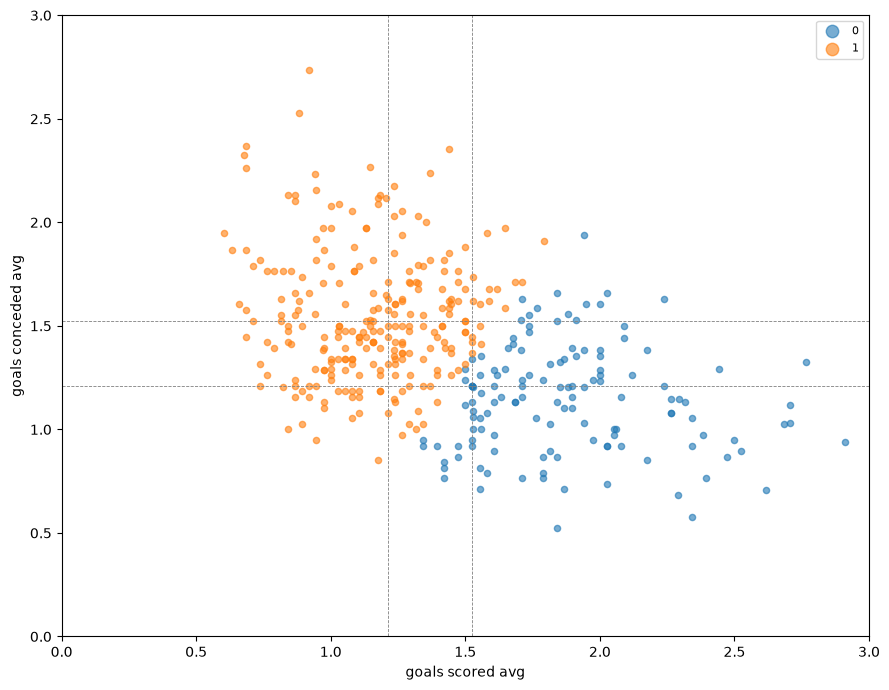

('0', '1') {'n_bets': 1285, 'capital': 273.196, 'wins': 279, 'profit': 5.804, 'roi': 0.0212} p=0.683
('1', '1') {'n_bets': 2250, 'capital': 646.75, 'wins': 632, 'profit': -14.75, 'roi': -0.0228} p=0.499
('1', '0') {'n_bets': 1298, 'capital': 337.534, 'wins': 322, 'profit': -15.534, 'roi': -0.046} p=0.343
('0', '0') {'n_bets': 704, 'capital': 182.101, 'wins': 150, 'profit': -32.101, 'roi': -0.1763} p=0.006


In [17]:
cluster_roi(2)

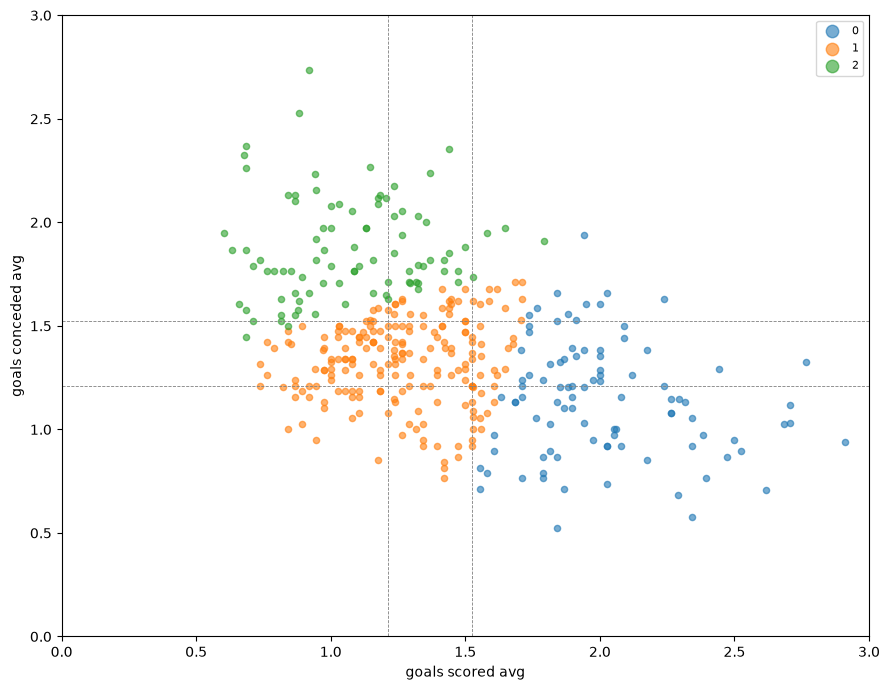

('2', '0') {'n_bets': 439, 'capital': 103.004, 'wins': 115, 'profit': 11.996, 'roi': 0.1165} p=0.177
('2', '2') {'n_bets': 455, 'capital': 127.775, 'wins': 139, 'profit': 11.225, 'roi': 0.0878} p=0.251
('1', '2') {'n_bets': 669, 'capital': 175.9, 'wins': 185, 'profit': 9.1, 'roi': 0.0517} p=0.429
('0', '2') {'n_bets': 422, 'capital': 75.445, 'wins': 82, 'profit': 6.555, 'roi': 0.0869} p=0.409
('2', '1') {'n_bets': 663, 'capital': 193.09, 'wins': 192, 'profit': -1.09, 'roi': -0.0056} p=0.966
('0', '1') {'n_bets': 630, 'capital': 139.875, 'wins': 126, 'profit': -13.875, 'roi': -0.0992} p=0.196
('1', '0') {'n_bets': 659, 'capital': 175.805, 'wins': 150, 'profit': -25.805, 'roi': -0.1468} p=0.025
('0', '0') {'n_bets': 398, 'capital': 100.397, 'wins': 74, 'profit': -26.397, 'roi': -0.2629} p=0.002
('1', '1') {'n_bets': 1202, 'capital': 348.29, 'wins': 320, 'profit': -28.29, 'roi': -0.0812} p=0.075


In [18]:
cluster_roi(3)

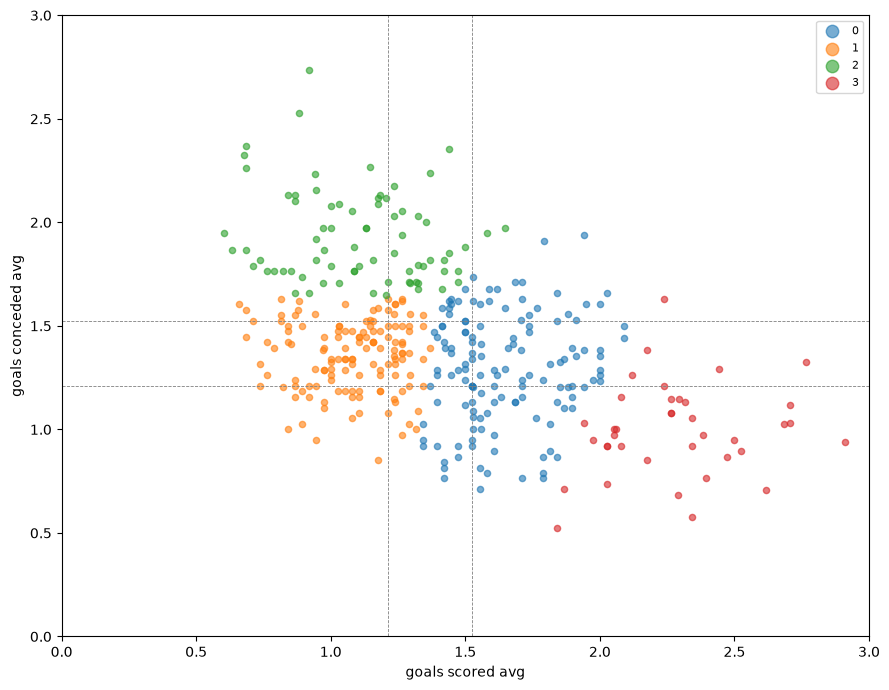

('0', '2') {'n_bets': 403, 'capital': 88.745, 'wins': 109, 'profit': 20.255, 'roi': 0.2282} p=0.019
('2', '1') {'n_bets': 373, 'capital': 110.773, 'wins': 126, 'profit': 15.227, 'roi': 0.1375} p=0.089
('2', '0') {'n_bets': 389, 'capital': 102.607, 'wins': 116, 'profit': 13.393, 'roi': 0.1305} p=0.134
('0', '1') {'n_bets': 549, 'capital': 137.815, 'wins': 139, 'profit': 1.185, 'roi': 0.0086} p=0.922
('2', '2') {'n_bets': 326, 'capital': 90.44, 'wins': 91, 'profit': 0.56, 'roi': 0.0062} p=0.951
('2', '3') {'n_bets': 167, 'capital': 35.054, 'wins': 34, 'profit': -1.054, 'roi': -0.0301} p=0.924
('3', '2') {'n_bets': 159, 'capital': 23.269, 'wins': 19, 'profit': -4.269, 'roi': -0.1835} p=0.371
('0', '3') {'n_bets': 209, 'capital': 53.378, 'wins': 47, 'profit': -6.378, 'roi': -0.1195} p=0.342
('1', '2') {'n_bets': 357, 'capital': 97.648, 'wins': 90, 'profit': -7.648, 'roi': -0.0783} p=0.406
('3', '3') {'n_bets': 81, 'capital': 19.86, 'wins': 12, 'profit': -7.86, 'roi': -0.3958} p=0.052
('1',

In [19]:
cluster_roi(4)

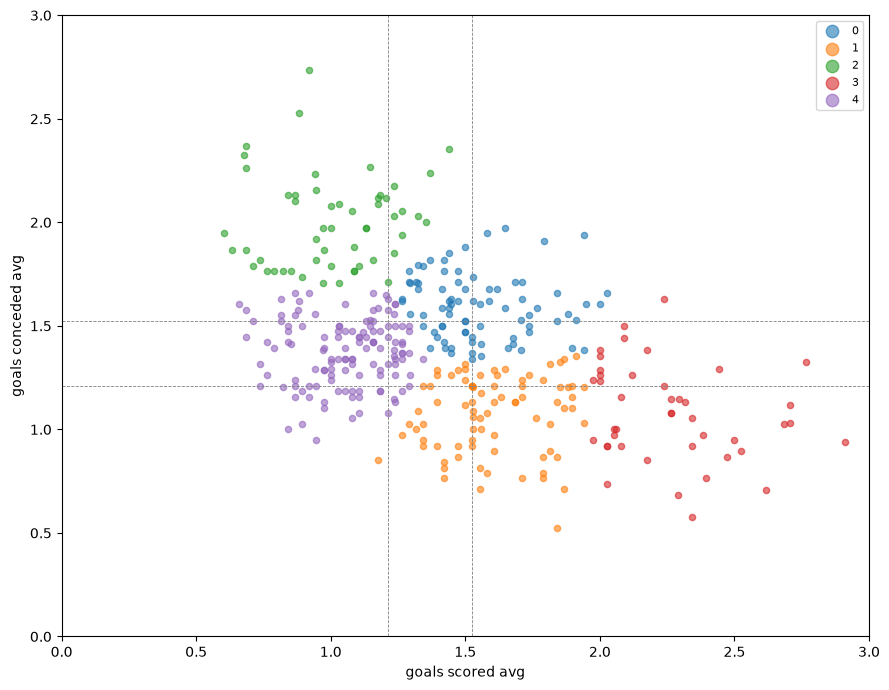

('0', '2') {'n_bets': 198, 'capital': 47.024, 'wins': 59, 'profit': 11.976, 'roi': 0.2547} p=0.054
('0', '0') {'n_bets': 252, 'capital': 65.742, 'wins': 75, 'profit': 9.258, 'roi': 0.1408} p=0.196
('0', '4') {'n_bets': 253, 'capital': 69.427, 'wins': 78, 'profit': 8.573, 'roi': 0.1235} p=0.231
('2', '4') {'n_bets': 250, 'capital': 74.686, 'wins': 82, 'profit': 7.314, 'roi': 0.0979} p=0.333
('1', '2') {'n_bets': 154, 'capital': 31.162, 'wins': 37, 'profit': 5.838, 'roi': 0.1873} p=0.269
('0', '3') {'n_bets': 179, 'capital': 42.461, 'wins': 44, 'profit': 1.539, 'roi': 0.0362} p=0.792
('2', '0') {'n_bets': 217, 'capital': 59.076, 'wins': 60, 'profit': 0.924, 'roi': 0.0156} p=0.879
('4', '1') {'n_bets': 428, 'capital': 123.618, 'wins': 124, 'profit': 0.382, 'roi': 0.0031} p=0.958
('2', '3') {'n_bets': 117, 'capital': 24.297, 'wins': 23, 'profit': -1.297, 'roi': -0.0534} p=0.821
('2', '2') {'n_bets': 167, 'capital': 47.118, 'wins': 45, 'profit': -2.118, 'roi': -0.045} p=0.796
('1', '4') {'n

In [20]:
cluster_roi(5)

In [21]:
# some combinations give low p-value - worth exploring further.

In [39]:
def cluster_roi2(n_clusters):
    km = KMeans(n_clusters=n_clusters, random_state=0)
    final[f'kmeans_cluster{n_clusters}'] = km.fit_predict(final[['season_goals_for_avg', 'season_goals_agst_avg']]).astype(str)
    plot_foragst_scatter(final, f'kmeans_cluster{n_clusters}')

    sub = abt[abt['hmt_game_number'] > 8].copy()
    sub['hmt_km'] = km.predict(sub[['hmt_season_goals_for_avg', 'hmt_season_goals_agst_avg']].rename(columns=lambda c: c.replace('hmt_', ''))).astype(str)
    sub['awt_km'] = km.predict(sub[['awt_season_goals_for_avg', 'awt_season_goals_agst_avg']].rename(columns=lambda c: c.replace('awt_', ''))).astype(str)

    groups = {k: g for k, g in sub.groupby(['hmt_km', 'awt_km'])}
    results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
    for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
        g = groups[k]
        pval = binomtest(r['wins'], r['n_bets'], g['mrkt_draw_impl'].mean()).pvalue
        print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")
        print(portfolio_breakdown(g['mrkt_draw_impl'], g['t_draw_flg'], g['league'], g['season']))
        print()


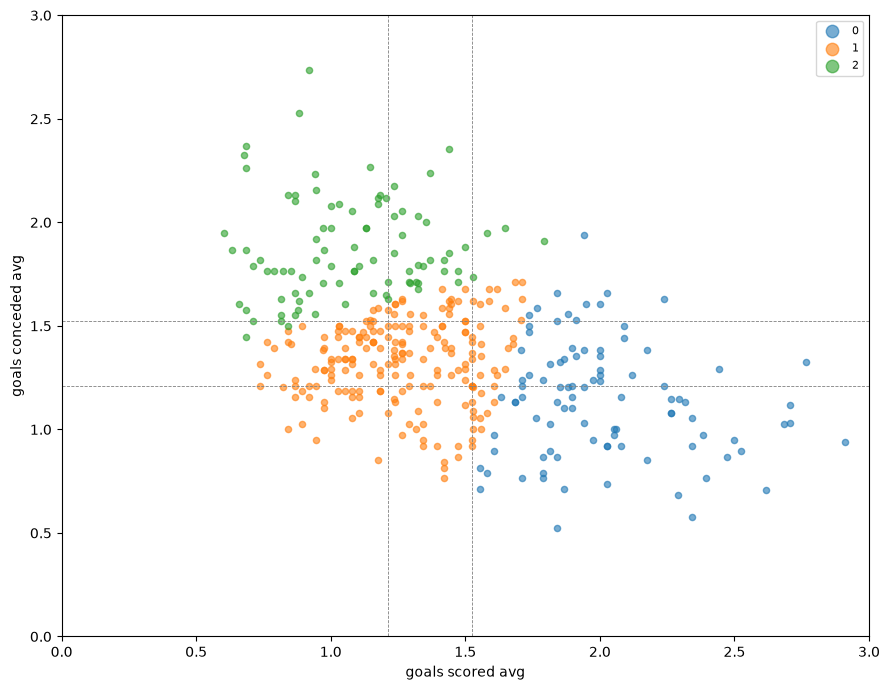

('2', '0') roi=0.117  n=439  p=0.177
season     2223    2324    2425    2526     ALL
england  0.3579 -0.0279 -0.1908  0.4548  0.1257
france   0.4681 -1.0000 -0.1019  0.0115  0.1444
germany -0.0738 -0.2514  0.3191  0.4699  0.1266
italy    0.2579 -0.2161 -0.1850  0.3743  0.0050
spain    0.0190  1.1578 -1.0000  0.4301  0.1877
ALL      0.2356 -0.0332 -0.1255  0.3921  0.1165

('2', '2') roi=0.088  n=455  p=0.251
season     2223    2324    2425    2526     ALL
england  0.0578 -0.2891 -0.4977 -0.4608 -0.2857
france  -0.1031 -0.6416 -0.7816  0.0855 -0.2648
germany -0.1516  0.5858  0.0256  0.1663  0.2492
italy    0.4344  0.4359  0.5718 -0.1312  0.3754
spain    0.7192  0.1031  0.2293  0.2941  0.4187
ALL      0.0934  0.2306 -0.0938  0.0462  0.0878

('1', '2') roi=0.052  n=669  p=0.429
season     2223    2324    2425    2526     ALL
england -0.2400 -0.0458  0.3768  0.4015  0.0923
france   0.1534 -0.0534 -0.2293  0.5254  0.0994
germany -0.1852  0.8005 -0.1186 -0.1030  0.0672
italy    0.3783  0.3346

In [40]:
cluster_roi2(3)

In [24]:
sub

,match_id,league,season,hmt_name,awt_name,date,time,day_of_week,season_game_number,gameweek,...,t_away_goals,t_result,t_home_flg,t_draw_flg,t_away_flg,t_goals_diff,t_goals_total,t_home_profit,t_draw_profit,t_away_profit
77,335ed036e58dfb983916730ad3958bde,england,2223,Bournemouth,Leicester,2022-10-08,15:00,Saturday,78,8,...,1,H,True,False,False,1,3,0.717,-0.275,-0.478
79,2095820f01e7f5566cd289ba9cd9d2db,england,2223,Man City,Southampton,2022-10-08,15:00,Saturday,80,8,...,0,H,True,False,False,4,4,0.107,-0.097,-0.047
80,309e502ce16fa8919aec781bc737abad,england,2223,Newcastle,Brentford,2022-10-08,15:00,Saturday,81,9,...,1,H,True,False,False,4,6,0.444,-0.255,-0.228
83,d2a8f6a6f055098dc23c25ba223aec1f,england,2223,West Ham,Fulham,2022-10-09,14:00,Sunday,84,9,...,1,H,True,False,False,2,4,0.438,-0.256,-0.219
84,70e3f92c52fc55f7da56c903d3459902,england,2223,Arsenal,Liverpool,2022-10-09,16:30,Sunday,85,9,...,2,H,True,False,False,1,5,0.612,-0.269,-0.382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7076,73d06d765606e35eec658d6407e098dd,france,2526,Lyon,Lens,2026-05-17,20:00,Sunday,301,34,...,4,A,False,False,True,-4,4,-0.578,-0.248,0.752
7077,81f36d0977e7c5eee2e843053422cabb,france,2526,Marseille,Rennes,2026-05-17,20:00,Sunday,302,34,...,1,H,True,False,False,2,4,0.497,-0.271,-0.300
7078,fca5c2f96776f2be1f78aa7f707e8e75,france,2526,Nice,Metz,2026-05-17,20:00,Sunday,303,34,...,0,D,False,True,False,0,0,-0.746,0.804,-0.129
7079,6576c1b28cd84f0884785ec63746c222,france,2526,Paris FC,Paris SG,2026-05-17,20:00,Sunday,304,34,...,1,H,True,False,False,1,3,0.806,-0.220,-0.658


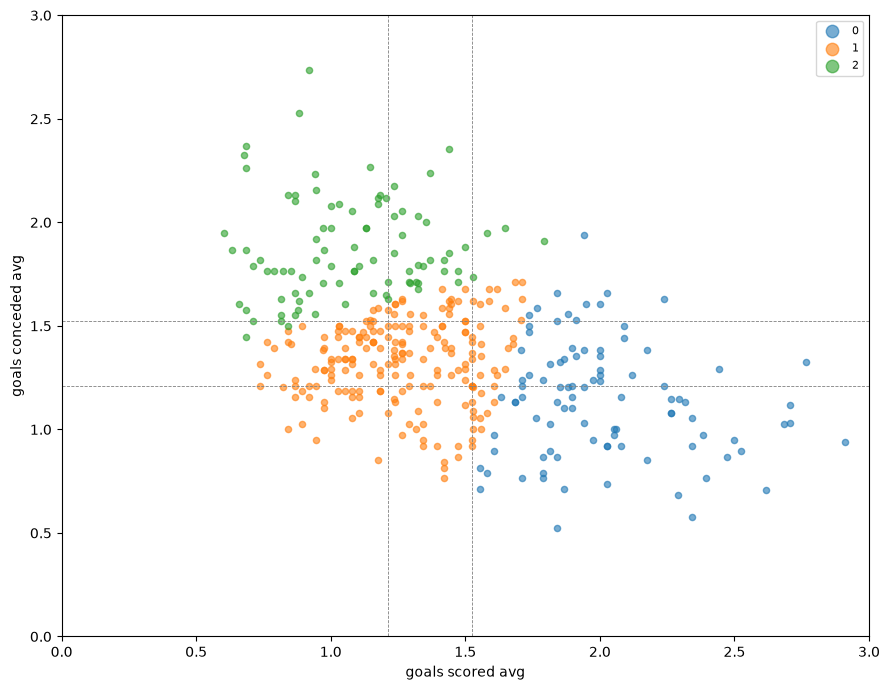

('0', '0') roi=0.117  n=398  p=0.031
season     2223    2324    2425    2526     ALL
england  0.2060  0.1591  0.1588  0.0796  0.1588
france   0.3404  0.1344  0.1313  0.6690  0.3454
germany  0.0993 -0.0287 -0.1325  0.0537 -0.0043
italy    0.4201  0.0148 -0.3680  0.0077  0.0167
spain    0.5157  0.2538 -0.3714  0.1889  0.0988
ALL      0.2754  0.1064 -0.0755  0.2041  0.1166

('1', '0') roi=-0.018  n=659  p=0.797
season     2223    2324    2425    2526     ALL
england  0.0380  0.0362  0.3597 -0.0217  0.1305
france   0.2942 -0.5751  0.0483  0.5277  0.1260
germany  0.3226 -0.6278 -0.3078 -0.7632 -0.1952
italy   -0.1518 -0.1784  0.0680 -0.4942 -0.1812
spain    0.2883 -0.2914 -0.0357 -0.0022 -0.0495
ALL      0.1336 -0.2442  0.0575 -0.0413 -0.0180

('0', '1') roi=-0.029  n=630  p=0.316
season     2223    2324    2425    2526     ALL
england  0.0902 -0.0765 -0.2743 -0.0533 -0.0757
france  -0.3657 -0.2482  0.1134 -0.2277 -0.1907
germany  0.0030  0.1065 -0.0210  0.2850  0.0706
italy   -0.1482  0.05

In [41]:
    n_clusters = 3
    km = KMeans(n_clusters=n_clusters, random_state=0)
    final[f'kmeans_cluster{n_clusters}'] = km.fit_predict(final[['season_goals_for_avg', 'season_goals_agst_avg']]).astype(str)
    plot_foragst_scatter(final, f'kmeans_cluster{n_clusters}')

    sub = abt[abt['hmt_game_number'] > 8].copy()
    sub['hmt_km'] = km.predict(sub[['hmt_season_goals_for_avg', 'hmt_season_goals_agst_avg']].rename(columns=lambda c: c.replace('hmt_', ''))).astype(str)
    sub['awt_km'] = km.predict(sub[['awt_season_goals_for_avg', 'awt_season_goals_agst_avg']].rename(columns=lambda c: c.replace('awt_', ''))).astype(str)

    groups = {k: g for k, g in sub.groupby(['hmt_km', 'awt_km'])}
    results = {k: portfolio_roi(g['mrkt_home_impl'], g['t_home_flg']) for k, g in groups.items()}
    for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
        g = groups[k]
        pval = binomtest(r['wins'], r['n_bets'], g['mrkt_home_impl'].mean()).pvalue
        print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")
        print(portfolio_breakdown(g['mrkt_home_impl'], g['t_home_flg'], g['league'], g['season']))
        print()

In [26]:
g = sub[(sub['hmt_km'] == '0') & (sub['awt_km'] == '0')]
g.head()

,match_id,league,season,hmt_name,awt_name,date,time,day_of_week,season_game_number,gameweek,...,t_home_flg,t_draw_flg,t_away_flg,t_goals_diff,t_goals_total,t_home_profit,t_draw_profit,t_away_profit,hmt_km,awt_km
84,70e3f92c52fc55f7da56c903d3459902,england,2223,Arsenal,Liverpool,2022-10-09,16:30,Sunday,85,9,...,True,False,False,1,5,0.612,-0.269,-0.382,0,0
96,5618310798dd1832ac2373afdbbfc0de,england,2223,Liverpool,Man City,2022-10-16,16:30,Sunday,97,10,...,True,False,False,1,1,0.733,-0.246,-0.524,0,0
100,d76ceafc7fb8ba89aa3ff33f918dbeff,england,2223,Brentford,Chelsea,2022-10-19,19:30,Wednesday,101,11,...,False,True,False,0,0,-0.209,0.745,-0.575,0,0
114,36d3b4ea59660e52f4c5cac3f9f6ab2f,england,2223,Tottenham,Newcastle,2022-10-23,16:30,Sunday,115,12,...,False,False,True,-1,3,-0.478,-0.279,0.717,0,0
135,a21f5fac7150c459cca949f22207f05c,england,2223,Tottenham,Liverpool,2022-11-06,16:30,Sunday,136,14,...,False,False,True,-1,3,-0.305,-0.272,0.537,0,0


In [27]:
print(portfolio_breakdown(g['mrkt_home_impl'], g['t_home_flg'], g['league'],g['season']))

season     2223    2324    2425    2526     ALL
england  0.2060  0.1591  0.1588  0.0796  0.1588
france   0.3404  0.1344  0.1313  0.6690  0.3454
germany  0.0993 -0.0287 -0.1325  0.0537 -0.0043
italy    0.4201  0.0148 -0.3680  0.0077  0.0167
spain    0.5157  0.2538 -0.3714  0.1889  0.0988
ALL      0.2754  0.1064 -0.0755  0.2041  0.1166


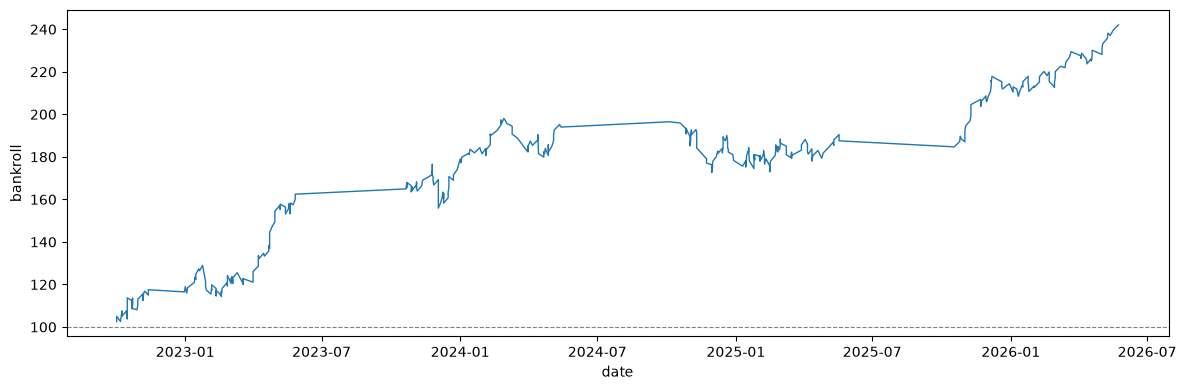

{'n_bets': 398,
 'capital': 1106.7158,
 'wins': 208,
 'profit': 142.0671,
 'roi': 0.1284,
 'bankroll_roi': 1.4207}

In [28]:
portfolio_kelly(g['mrkt_home_impl'], g['t_home_flg'], plot=True, dates=g['date'], model_probs=g['mrkt_home_impl'] * 1.05)